<h1 style="text-align:center;">AF3 Motif Builder</h1>

In [17]:
import glob
import os
import shutil
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from Bio.PDB import MMCIFParser
from Bio.SeqUtils import seq1

# Build motif

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_8387/2511226765.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_8387/2511226765.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]


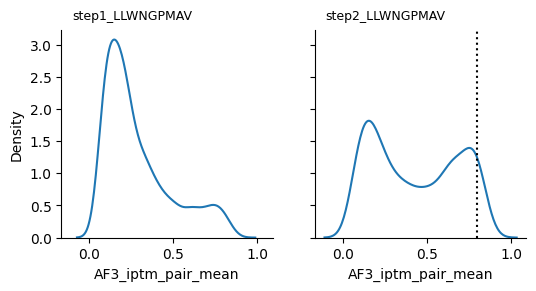

In [7]:
fig, axes = plt.subplots(1,2, figsize=(6,2.7), sharex=True, sharey=True)
topdirs = ['step1_LLWNGPMAV', 'step2_LLWNGPMAV']

for cnt, topdir in enumerate(topdirs):
    ax = axes[cnt]
    df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]

    sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax)
    sns.despine()
    if cnt == 1:
        ax.axvline(0.8, color='black', linestyle=':')
    ax.text(0.05, 1.05, topdir, transform=ax.transAxes, fontsize=9)

In [5]:
# prepaire csv for motif building
topdirs = ['step1_LLWNGPMAV', 'step2_LLWNGPMAV']

baselines = []
models = []
for topdir in topdirs:
    df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
    anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_input.txt', delim_whitespace=True)

    df = pd.merge(df, anno, on='id')

    baseline = df.copy()
    baselines.append(baseline)
    baseline.to_csv(f'{topdir}/baseline.csv', index=False)

    thresholds = [0.5, 0.7, 0.8, 0.9]

    lst = []
    for threshold in thresholds:
        tmp = df.copy()
        below = tmp[tmp['AF3_iptm_pair_mean'] < threshold]
        below['model'] = f'ipTM < {threshold}'
        lst.append(below)
        
        above = tmp[tmp['AF3_iptm_pair_mean'] > threshold]
        above['model'] = f'ipTM > {threshold}'
        lst.append(above)

    df = pd.concat(lst)
    models.append(df)
    df.to_csv(f'{topdir}/enrichment_by_ipTM.csv', index=False)
    
baseline = pd.concat(baselines)
baseline.to_csv('baseline.csv', index=False)

models = pd.concat(models)
models.to_csv('enrichment_by_ipTM.csv', index=False)

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95721/73288586.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95721/73288586.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_input.txt', delim_whitespace=True)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95721/73288586.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin

In [3]:
# remove non-functional TCRs
genes = ['TRAV', 'TRAJ', 'TRBV', 'TRBJ']

dico = {}
topdir = '/Users/roessner/Documents/PostDoc/Data/MixTCRviz/data_raw/HomoSapiens'
for gene in genes:
    anno = pd.read_csv(f'{topdir}/{gene}.csv')
    anno = anno.rename(columns={anno.columns[0] : gene})
    anno = anno[anno['gene_type'] == 'F']
    
    dico[gene] = anno[gene].values


topdir = 'step2_LLWNGPMAV'
df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_input.txt', delim_whitespace=True)
df = pd.merge(df, anno, on='id')

for gene in genes:
    df = df[df[gene].isin(dico[gene])]

baseline = df.copy()
baseline.to_csv(f'{topdir}/baseline_clean.csv', index=False)

thresholds = [0.5, 0.7, 0.8, 0.9]

lst = []
for threshold in thresholds:
    tmp = df.copy()
    below = tmp[tmp['AF3_iptm_pair_mean'] < threshold]
    below['model'] = f'ipTM < {threshold}'
    lst.append(below)
    
    above = tmp[tmp['AF3_iptm_pair_mean'] > threshold]
    above['model'] = f'ipTM > {threshold}'
    lst.append(above)

df = pd.concat(lst)
df.to_csv(f'{topdir}/enrichment_by_ipTM_clean.csv', index=False)
print(df.head())

         id  AF3_iptm_pair_mean      TRAV    TRAJ             cdr3_TRA  \
2   tcr0003              0.1675    TRAV34  TRAJ26   CGADILVLADNYGQNFVF   
3   tcr0004              0.2475   TRAV8-1  TRAJ26     CAVNLRSPNYGQNFVF   
7   tcr0008              0.1650   TRAV8-1  TRAJ45       CAVHPGRGADGLTF   
11  tcr0012              0.2900  TRAV12-3  TRAJ48  CAMSPPTGISNFGNEKLTF   
12  tcr0013              0.3850    TRAV34  TRAJ47    CGAVSGHSKEYGNKLVF   

        TRBV     TRBJ             cdr3_TRB    peptide        MHC      species  \
2    TRBV7-7  TRBJ1-5      CASSPAEGVNQPQHF  LLWNGPMAV  HLA_A0201  HomoSapiens   
3   TRBV11-2  TRBJ2-3  CASSLAVLATAGSTDTQYF  LLWNGPMAV  HLA_A0201  HomoSapiens   
7    TRBV5-4  TRBJ1-3         CASTFYRYTIYF  LLWNGPMAV  HLA_A0201  HomoSapiens   
11  TRBV12-3  TRBJ1-3        CASSETTRNTIYF  LLWNGPMAV  HLA_A0201  HomoSapiens   
12  TRBV12-3  TRBJ1-1   CASSAVGLTSRRNTEAFF  LLWNGPMAV  HLA_A0201  HomoSapiens   

   MHC_allele_a MHC_allele_b       model  
2     HLA_A0201          

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_80856/2217672051.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_80856/2217672051.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_input.txt', delim_whitespace=True)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_80856/2217672051.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

# Inspect high confidence models

In [14]:
threshold = 0.8
topdir = 'step2_LLWNGPMAV'

df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
df = df[df['AF3_iptm_pair_mean'] > 0.8]
anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_input.txt', delim_whitespace=True)
df = pd.merge(df, anno, on='id')

os.makedirs(f'{topdir}/high_conf_models', exist_ok=True)
for id in df['id'].values:
    shutil.copy(f'{topdir}/AF3_outputs/{id}/{id}_model.cif',f'{topdir}/high_conf_models/{id}.cif')

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_8387/3123667422.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_8387/3123667422.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_input.txt', delim_whitespace=True)


# Curate file with CDR plddts for motif annotation

In [48]:
def extract_cdr_plddt(cif_path, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"], threshold=10):
    """
    Extract plddt of CDRs based on the respective sequences.
    """

    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("cif", cif_path)
    model = structure[0]

    cdr_plddt = {}

    for chain_label, chain_id in chain_map.items():
        chain_obj = model[chain_id]

        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join(seq1(res.get_resname()) for res in residues)

        cdr_dict_chain = {}
        for key, value in cdr_dict.items():
            if key.endswith(chain_id[-1]):
                cdr_dict_chain[key] = value

        for cdr, cdr_seq in cdr_dict_chain.items():
            L = len(cdr_seq)

            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: {cdr} not found in {chain_id} of {cif_path}")
                continue

            end_idx = start_idx + L

            plddts = []
            for res in residues[start_idx:end_idx]:
                res_plddts = []
                for atom in res.get_atoms():
                    res_plddts.append(atom.get_bfactor())

                mean_res_plddts = np.mean(res_plddts) / 100
                plddts.append(np.round(mean_res_plddts, 2))

            cdr_plddt[cdr] = np.array(plddts) 

    return cdr_plddt

def split_cdr3(cdr3, v_gene, j_gene, v_ref, j_ref):
    """
    Split CDR3 into V, insertion, and J sequences.
    Returns: v_seq_str, insertion_seq_str, j_seq_str
    """
    # Get reference sequences
    v_seq = v_ref.loc[v_ref['Gene']==v_gene, 'CDR3'].values
    j_seq = j_ref.loc[j_ref['Gene']==j_gene, 'CDR3'].values
    
    if len(v_seq)==0 or len(j_seq)==0:
        # If reference is missing, put everything as 'Unknown'
        return None, None
    
    v_seq = v_seq[0]
    j_seq = j_seq[0]
    
    # Match V at the start
    v_len = 0
    for i in range(min(len(v_seq), len(cdr3))):
        if cdr3[i] == v_seq[i]:
            v_len += 1
        else:
            break
    
    # Match J at the end
    j_len = 0
    for i in range(1, min(len(j_seq), len(cdr3))+1):
        if cdr3[-i] == j_seq[-i]:
            j_len += 1
        else:
            break
    
    v_part = cdr3[:v_len]
    j_part = cdr3[len(cdr3)-j_len:] if j_len > 0 else ''
    insertion_part = cdr3[v_len:len(cdr3)-j_len] if len(cdr3) > v_len + j_len else ''
    
    # drop first C and last F/W
    v_part = v_part[1:]
    j_part = j_part[:-1]

    return v_part, j_part

In [62]:
topdir = 'step2_LLWNGPMAV'
df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_input.txt', delim_whitespace=True)
df = pd.merge(df, anno, on='id')
df = df.rename(columns={'cdr3_TRA' : 'CDR3A', 'cdr3_TRB' : 'CDR3B'})

genes = ['TRAV', 'TRBV']
for gene in genes:
    anno = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{gene}.csv')
    anno = anno.rename(columns={anno.columns[0]:gene})

    anno[f'CDR1{gene[-2]}'] = anno['CDR1'].str.replace('-', '', regex=False)
    anno[f'CDR2{gene[-2]}'] = anno['CDR2'].str.replace('-', '', regex=False)
    anno = anno[[gene, f'CDR1{gene[-2]}', f'CDR2{gene[-2]}']]

    df = pd.merge(df, anno, on=gene)

# reference dataframes to split cdr3 according to V/J contributions
TRAV_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRAV.csv').rename(columns={'Unnamed: 0':'Gene'})
TRAJ_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRAJ.csv').rename(columns={'Unnamed: 0':'Gene'})
TRBV_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRBV.csv').rename(columns={'Unnamed: 0':'Gene'})
TRBJ_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRBJ.csv').rename(columns={'Unnamed: 0':'Gene'})

lst = []
for idx, row in df.iterrows():
    cdr_dict = {cdr: str(row[cdr]).upper() for cdr in ["CDR1A","CDR2A","CDR3A","CDR1B","CDR2B","CDR3B"]}

    file = f'{topdir}/AF3_outputs/{row.id}/{row.id}_model.cif'
    
    cdr_plddts = extract_cdr_plddt(file, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"])
    
    # add cdr3 v/j part
    v_part, j_part = split_cdr3(row.CDR3A, row.TRAV, row.TRAJ, TRAV_ref, TRAJ_ref)
    cdr_plddts['CDR3AV'] = cdr_plddts['CDR3A'][:len(v_part)]
    cdr_plddts['CDR3AJ'] = cdr_plddts['CDR3A'][-len(j_part):]

    v_part, j_part = split_cdr3(row.CDR3B, row.TRBV, row.TRBJ, TRBV_ref, TRBJ_ref)
    cdr_plddts['CDR3BV'] = cdr_plddts['CDR3B'][:len(v_part)]
    cdr_plddts['CDR3BJ'] = cdr_plddts['CDR3B'][-len(j_part):]

    cdr_plddts['id'] = row.id
    cdr_plddts['TRAV'] = row.TRAV
    cdr_plddts['TRAJ'] = row.TRAJ
    cdr_plddts['TRBV'] = row.TRBV
    cdr_plddts['TRBJ'] = row.TRBJ
    cdr_plddts['CDR3A_seq'] = row.CDR3A
    cdr_plddts['CDR3B_seq'] = row.CDR3B
    lst.append(cdr_plddts)

df = pd.DataFrame(lst)   
df.to_csv(f'{topdir}/cdr_plddts.csv', index=False)

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_80856/2105005794.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_80856/2105005794.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_LLWNGPMAV_input.txt', delim_whitespace=True)
